In [2]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as st

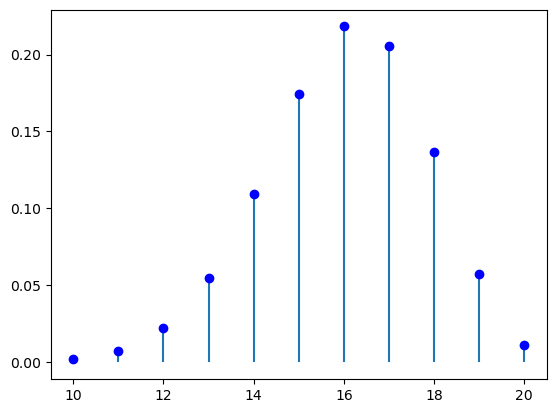

In [19]:
# 3
n = 20
p = 0.8

C = st.binom(n,p)


max_x = C.ppf(0.999)
min_x = C.ppf(0.001)
x = np.arange(min_x,max_x+1)


plt.vlines(x, 0, C.pmf(x))
plt.plot(x, C.pmf(x), 'bo')

plt.show()
# ho scelto il massimo utilizzando il 99esimo percentile, per comprendere una buona parte dei dati. ragionamento simile per il minimo

# esercizio 4


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
acq = pd.read_csv("data/acquisti.csv", sep=",")
acq.head()

,bottiglie_acquistate,bottiglie_rese,temperatura
0,3481.0,1324.0,18.0
1,3463.0,NaN,10.0
2,3464.0,1353.0,39.0
3,3527.0,986.0,0.0
4,3367.0,2190.0,-3.0


In [44]:
# 1
len(acq[acq.bottiglie_rese.isnull() | acq.temperatura.isnull() | acq.bottiglie_rese.isnull()])/len(acq) 

0.002

<Axes: >

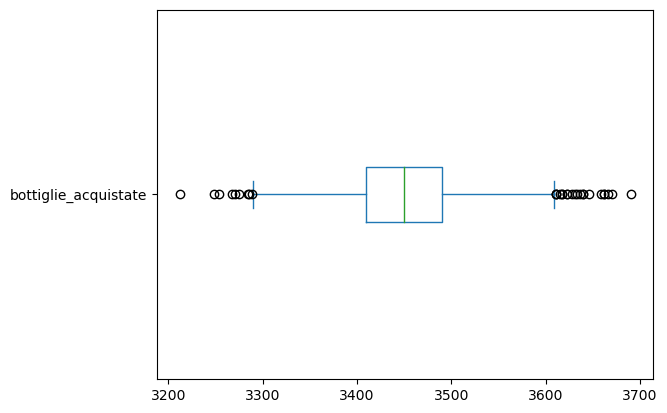

In [61]:
acq.bottiglie_acquistate.plot.box(vert=False)
# ho utilizzato l'istogramma perchè volevo rappresentare in maniera più chiara la frequenza di un certo bin di valori.
# essendo l'attributo quantitativo questo grafico rappresenta abbastanza la distribuzione

<Axes: ylabel='Frequency'>

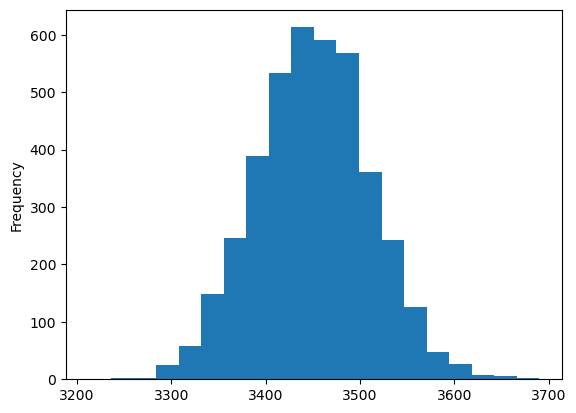

In [59]:
acq.bottiglie_acquistate.plot.hist(bins = 20)

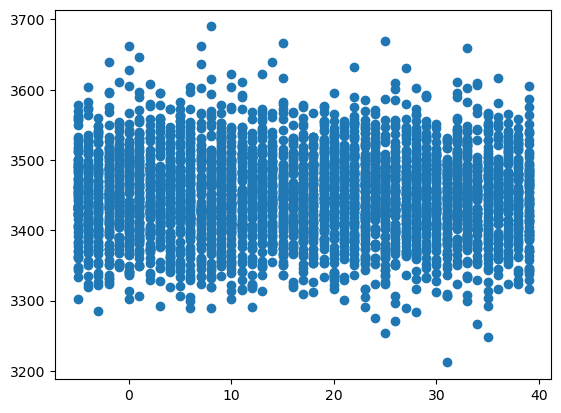

In [65]:
# 4. Valutate l'ipotesi che vi sia una relazione di tipo diretto tra gli attributi
# bottiglie_acquistate e temperatura, utilizzando in modo opportuno sia un metodo grafico
# sia un indice numerico. Commentate i risultati ottenuti.
plt.scatter(acq.temperatura, acq.bottiglie_acquistate)

In [67]:
acq.bottiglie_acquistate.corr(acq.temperatura)
# sembra non esserci correlazione tra i due attributi anche se lo trovo strano

-0.006180512682684298

In [84]:
# 5. Una bottiglia d'acqua costa 1€, e il distributore sconta 10 centesimi per ogni bottiglia
# resa. Aggiungete al dataset una colonna dal nome ricavo che contenga il ricavo settimanale
# per ogni caso
# ricavo = totale - bottiglie_rese*0.10
acq["ricavo"] = [(i[0]-i[1]*0.1) for i in acq.values]
acq

,bottiglie_acquistate,bottiglie_rese,temperatura,ricavo
0,3481.0,1324.0,18.0,3348.6
1,3463.0,NaN,10.0,NaN
2,3464.0,1353.0,39.0,3328.7
3,3527.0,986.0,0.0,3428.4
4,3367.0,2190.0,-3.0,3148.0
...,...,...,...,...
3995,3516.0,1046.0,7.0,3411.4
3996,3420.0,1669.0,32.0,3253.1
3997,3487.0,1472.0,14.0,3339.8
3998,3552.0,1957.0,9.0,3356.3


6. Valutate l'ipotesi che il ricavo settimanale di ogni acquisto sia ben descritto da un
modello normale, commentando i risultati ottenuti

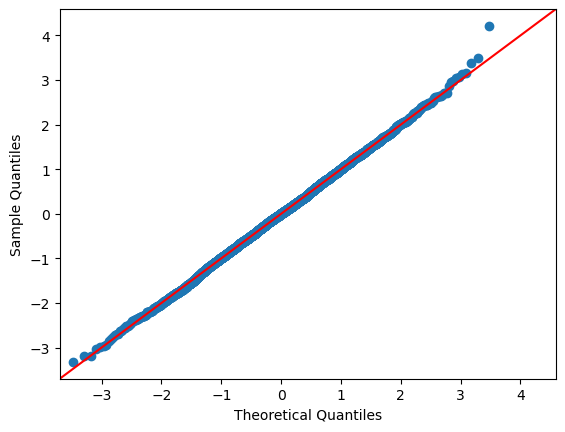

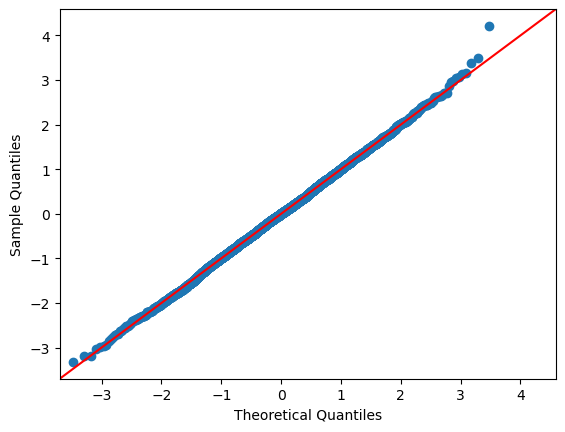

In [86]:
sm.qqplot(acq.ricavo.dropna(), fit=True, line='45') # è decisamente normale


In [ ]:
# 7 no

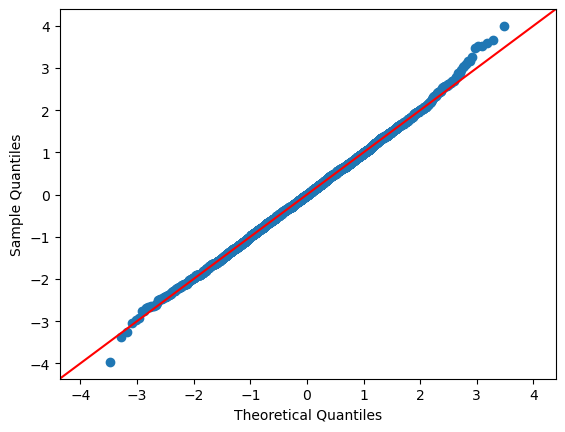

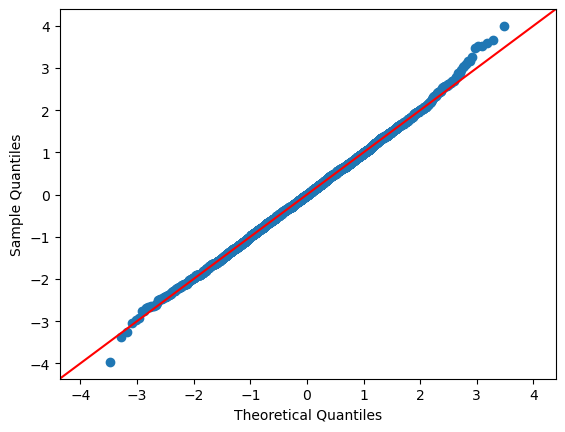

In [90]:
sm.qqplot(acq.bottiglie_acquistate.dropna(), fit=True, line='45') # anche questa è approssimativamente normale infatti il grafico
# quantile quantile si allinea sulla bisettrice 

In [103]:
mu = acq.bottiglie_acquistate.mean()
mu

3450.124124124124

In [92]:
len(acq.bottiglie_acquistate.dropna())

3996

è non distorto rispetto al valore atteso della variabile aleatori C_tot e inoltre è consistente in media quadratica. 

2. Stimate la deviazione standard della popolazione descritta dalla variabile aleatoria Ct ot,
specificando eventuali proprietà dello stimatore utilizzato. La dimensione del campione
utilzzato è la stessa del punto precendete? Perchè?

In [98]:
sig = np.sqrt(acq.bottiglie_acquistate.var())

la dimensione è la stessa dato che il campione è lo stesso inoltre è consistente in media quadratica e non distorto

In [97]:
E = acq.bottiglie_acquistate.mean() > 3600

In [102]:
z = st.norm()

1-z.cdf((3600-mu)/sig)

0.006273854495658315

In [101]:
mu/3600

0.9583678122567012

In [104]:
acq.ricavo.mean()

3299.6993485342023

In [116]:
2*z.cdf(10*np.sqrt(len(acq.ricavo))/acq.ricavo.std())-1

0.9999999999999978

<Axes: ylabel='Frequency'>

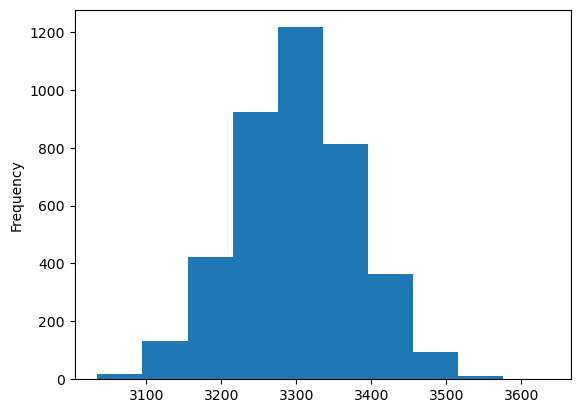

In [117]:
acq.ricavo.plot.hist()